# Data Cleaning
## Respiratory Disease Prediction from Environmental Factors

---

## Purpose

This notebook applies targeted cleaning to all six datasets.
All decisions are based on findings from `data_profiling_report.md`.

## Decisions from Profiling

| Dataset | Operations |
|---|---|
| PM2.5 | Drop negatives (8,306 in study period), cap at 99.5th percentile, parse mixed dates |
| NO2 | Drop negatives (2,694 in study period), cap at 99.5th percentile, parse mixed dates |
| Ozone | Drop 18 negatives, cap at 99.5th percentile, parse mixed dates |
| Temperature | Hard bounds only: drop below -80F (1 sentinel) and above 140F (79 surface heat) |
| Humidity | Filter to Relative Humidity rows only, drop 2 values above 100% |
| Respiratory | Filter to ARI + United States, no value cleaning needed |

Note: percentile caps are computed on study-period data only (2022-09-25 to 2025-10-31).

## Output

```
data/processed/
    pm25_daily.csv
    no2_daily.csv
    ozone_daily.csv
    temperature_daily.csv
    humidity_daily.csv
    respiratory_daily.csv
    master_daily.csv
```

## Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from functools import reduce

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

# Study period: bound by NSSP start (Sep 25 2022) and Temperature end (Oct 31 2025)
# Profiling finding: NSSP starts 9 months later than all EPA datasets
STUDY_START = '2022-09-25'
STUDY_END   = '2025-10-31'

print(f'Study period: {STUDY_START} to {STUDY_END}')

Study period: 2022-09-25 to 2025-10-31


## Step 1: Load Raw Data

In [2]:
def load_epa(folder, prefix):
    files = sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.startswith(prefix) and f.endswith('.csv')
    ])
    print(f'  {prefix}: {[os.path.basename(f) for f in files]}')
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
    df.columns = [c.strip() for c in df.columns]
    return df

print('Loading raw files...')
pm25_raw     = load_epa('data/raw/pm25',        'daily_88101')
no2_raw      = load_epa('data/raw/no2',          'daily_42602')
ozone_raw    = load_epa('data/raw/ozone',        'daily_44201')
temp_raw     = load_epa('data/raw/temperature',  'daily_TEMP')
humidity_raw = load_epa('data/raw/humidity',     'daily_RH_DP')
resp_raw     = pd.read_csv('data/raw/respiratory/nssp_respiratory.csv', low_memory=False)
resp_raw.columns = [c.strip() for c in resp_raw.columns]
print(f'  nssp_respiratory.csv')

print('\nRaw shapes:')
for name, df in [('PM2.5', pm25_raw), ('NO2', no2_raw), ('Ozone', ozone_raw),
                 ('Temperature', temp_raw), ('Humidity', humidity_raw), ('Respiratory', resp_raw)]:
    print(f'  {name:<15} {df.shape[0]:>10,} rows')

Loading raw files...
  daily_88101: ['daily_88101_2022.csv', 'daily_88101_2023.csv', 'daily_88101_2024.csv', 'daily_88101_2025.csv']
  daily_42602: ['daily_42602_2022.csv', 'daily_42602_2023.csv', 'daily_42602_2024.csv', 'daily_42602_2025.csv']
  daily_44201: ['daily_44201_2022.csv', 'daily_44201_2023.csv', 'daily_44201_2024.csv', 'daily_44201_2025.csv']
  daily_TEMP: ['daily_TEMP_2022.csv', 'daily_TEMP_2023.csv', 'daily_TEMP_2024.csv', 'daily_TEMP_2025.csv']
  daily_RH_DP: ['daily_RH_DP_2022.csv', 'daily_RH_DP_2023.csv', 'daily_RH_DP_2024.csv', 'daily_RH_DP_2025.csv']
  nssp_respiratory.csv

Raw shapes:
  PM2.5            2,915,841 rows
  NO2                562,605 rows
  Ozone            1,412,282 rows
  Temperature      1,184,025 rows
  Humidity           579,258 rows
  Respiratory        259,896 rows


---
## Step 2: Clean PM2.5, NO2, Ozone


Remove negative values: negative pollutant readings are physically impossible.
Cap at the 99.5th percentile: reduces extreme outliers while keeping real wildfire values.
Parse dates with format='mixed': needed because date formats differed across files.
Interpolate gaps up to 3 days: fills short outages, but leaves longer gaps unchanged.

In [3]:
def clean_pollutant(raw_df, col_name, cap_percentile=99.5):
    df = raw_df.copy()

    # Parse dates: format='mixed' handles both MM/DD/YYYY and YYYY-MM-DD across yearly files
    df['date'] = pd.to_datetime(df['Date Local'], format='mixed', errors='coerce')
    df = df.dropna(subset=['date'])

    # Parse measurement values
    df['value'] = pd.to_numeric(df['Arithmetic Mean'], errors='coerce')

    # Filter to study period before computing statistics so cap reflects study-period distribution
    df = df[(df['date'] >= STUDY_START) & (df['date'] <= STUDY_END)]

    # Drop negatives: physically impossible for PM2.5 (ug/m3), NO2 (ppb), Ozone (ppm)
    n_neg = (df['value'] < 0).sum()
    df = df[df['value'].isna() | (df['value'] >= 0)]

    # Cap at 99.5th percentile computed on study-period data only, not the full raw dataset
    cap = df['value'].quantile(cap_percentile / 100)
    n_capped = (df['value'] > cap).sum()
    df['value'] = df['value'].clip(upper=cap)

    # National daily mean across all monitoring stations
    daily = (
        df.groupby('date')
        .agg(value=('value', 'mean'), n_stations=('value', 'count'))
        .reset_index()
        .rename(columns={'value': col_name, 'n_stations': f'{col_name}_n_stations'})
    )

    # Reindex to full date range, interpolate gaps up to 3 consecutive days
    full_range = pd.DataFrame({'date': pd.date_range(STUDY_START, STUDY_END, freq='D')})
    daily = full_range.merge(daily, on='date', how='left')
    n_gaps = daily[col_name].isna().sum()
    daily[col_name] = daily[col_name].interpolate(method='linear', limit=3)
    n_still_missing = daily[col_name].isna().sum()

    daily = daily.sort_values('date').reset_index(drop=True)

    print(f'  Negatives dropped:  {n_neg:>7,}')
    print(f'  Values capped:      {n_capped:>7,}  (cap = {cap:.4f})')
    print(f'  Date gaps: {n_gaps} found | {n_gaps - n_still_missing} interpolated | {n_still_missing} still missing')
    print(f'  Final range: {daily[col_name].min():.4f} to {daily[col_name].max():.4f}')
    print(f'  Final shape: {daily.shape[0]} rows')
    return daily


print('Cleaning PM2.5...')
pm25_clean = clean_pollutant(pm25_raw, 'pm25')

print('\nCleaning NO2...')
no2_clean = clean_pollutant(no2_raw, 'no2')

print('\nCleaning Ozone...')
ozone_clean = clean_pollutant(ozone_raw, 'ozone')

Cleaning PM2.5...
  Negatives dropped:    8,306
  Values capped:       11,344  (cap = 38.0000)
  Date gaps: 0 found | 0 interpolated | 0 still missing
  Final range: 3.5829 to 21.1503
  Final shape: 1133 rows

Cleaning NO2...
  Negatives dropped:    2,694
  Values capped:        2,219  (cap = 32.9625)
  Date gaps: 0 found | 0 interpolated | 0 still missing
  Final range: 3.0297 to 16.7653
  Final shape: 1133 rows

Cleaning Ozone...
  Negatives dropped:       18
  Values capped:        5,540  (cap = 0.0623)
  Date gaps: 0 found | 0 interpolated | 0 still missing
  Final range: 0.0185 to 0.0453
  Final shape: 1133 rows


---
## Step 3: Clean Temperature

Drop values below -80°F: removes impossible low readings caused by sensor error.
Drop values above 140°F: removes unrealistic high readings likely caused by surface heat.
Use hard bounds: temperature has clear physical limits, so this works better than percentile capping.
No unit conversion needed: all values were already in Fahrenheit.


In [4]:
def clean_temperature(raw_df):
    df = raw_df.copy()

    # Confirm units before applying bounds
    if 'Units of Measure' in df.columns:
        units = df['Units of Measure'].value_counts().to_dict()
        print(f'  Units: {units}')

    df['date'] = pd.to_datetime(df['Date Local'], format='mixed', errors='coerce')
    df = df.dropna(subset=['date'])
    df['value'] = pd.to_numeric(df['Arithmetic Mean'], errors='coerce')

    # Hard physical bounds — not percentile-based
    # Lower: -80F  
    # Upper: 140F  
    n_below = (df['value'] < -80).sum()
    n_above = (df['value'] > 140).sum()
    df = df[df['value'].isna() | ((df['value'] >= -80) & (df['value'] <= 140))]
    print(f'  Dropped below -80F: {n_below}  (includes 1 sentinel at -1177.67F)')
    print(f'  Dropped above 140F: {n_above}  (surface radiant heat artifacts)')

    df = df[(df['date'] >= STUDY_START) & (df['date'] <= STUDY_END)]

    daily = (
        df.groupby('date')
        .agg(temperature=('value', 'mean'), temp_n_stations=('value', 'count'))
        .reset_index()
    )

    full_range = pd.DataFrame({'date': pd.date_range(STUDY_START, STUDY_END, freq='D')})
    daily = full_range.merge(daily, on='date', how='left')
    n_gaps = daily['temperature'].isna().sum()
    daily['temperature'] = daily['temperature'].interpolate(method='linear', limit=3)
    n_still_missing = daily['temperature'].isna().sum()
    print(f'  Date gaps: {n_gaps} found | {n_gaps - n_still_missing} interpolated | {n_still_missing} still missing')

    daily = daily.sort_values('date').reset_index(drop=True)
    print(f'  Final range: {daily["temperature"].min():.2f}F to {daily["temperature"].max():.2f}F')
    print(f'  Final shape: {daily.shape[0]} rows')
    return daily

print('Cleaning Temperature...')
temp_clean = clean_temperature(temp_raw)

Cleaning Temperature...
  Units: {'Degrees Fahrenheit': 1184025}
  Dropped below -80F: 1  (includes 1 sentinel at -1177.67F)
  Dropped above 140F: 79  (surface radiant heat artifacts)
  Date gaps: 0 found | 0 interpolated | 0 still missing
  Final range: 21.81F to 80.90F
  Final shape: 1133 rows


---
## Step 4: Clean Humidity

Filter to Relative Humidity only: removes Dew Point rows so the averages stay meaningful.
Drop values above 100%: relative humidity cannot exceed 100%.
No negative RH values remained after filtering: the raw negative minimum came from Dew Point rows, not actual humidity values.

In [5]:
def clean_humidity(raw_df):
    df = raw_df.copy()

    # Filter to Relative Humidity rows only
    # Critical: without this step, Dew Point values corrupt the average
    if 'Parameter Name' in df.columns:
        n_before = len(df)
        df = df[df['Parameter Name'].str.contains('Relative Humidity', case=False, na=False)]
        print(f'  Dew Point rows removed: {n_before - len(df):,}')
        print(f'  Relative Humidity rows: {len(df):,}')
    else:
        print('  WARNING: Parameter Name column missing. Cannot filter to RH only.')

    df['date'] = pd.to_datetime(df['Date Local'], format='mixed', errors='coerce')
    df = df.dropna(subset=['date'])
    df['value'] = pd.to_numeric(df['Arithmetic Mean'], errors='coerce')

    # Drop impossible values: RH must be 0-100%
    # Profiling confirmed: 0 below 0%, 2 above 100% in RH-only rows
    n_below = (df['value'] < 0).sum()
    n_above = (df['value'] > 100).sum()
    df = df[df['value'].isna() | ((df['value'] >= 0) & (df['value'] <= 100))]
    print(f'  Dropped below 0%:   {n_below}  (expected 0 — profiling confirmed)')
    print(f'  Dropped above 100%: {n_above}  (calibration drift)')

    df = df[(df['date'] >= STUDY_START) & (df['date'] <= STUDY_END)]

    daily = (
        df.groupby('date')
        .agg(humidity=('value', 'mean'), humidity_n_stations=('value', 'count'))
        .reset_index()
    )

    full_range = pd.DataFrame({'date': pd.date_range(STUDY_START, STUDY_END, freq='D')})
    daily = full_range.merge(daily, on='date', how='left')
    n_gaps = daily['humidity'].isna().sum()
    daily['humidity'] = daily['humidity'].interpolate(method='linear', limit=3)
    n_still_missing = daily['humidity'].isna().sum()
    print(f'  Date gaps: {n_gaps} found | {n_gaps - n_still_missing} interpolated | {n_still_missing} still missing')

    daily = daily.sort_values('date').reset_index(drop=True)
    print(f'  Final range: {daily["humidity"].min():.2f}% to {daily["humidity"].max():.2f}%')
    print(f'  Final shape: {daily.shape[0]} rows')
    return daily

print('Cleaning Humidity...')
humidity_clean = clean_humidity(humidity_raw)

Cleaning Humidity...
  Dew Point rows removed: 43,518
  Relative Humidity rows: 535,740
  Dropped below 0%:   0  (expected 0 — profiling confirmed)
  Dropped above 100%: 2  (calibration drift)
  Date gaps: 0 found | 0 interpolated | 0 still missing
  Final range: 43.72% to 85.91%
  Final shape: 1133 rows


---
## Step 5: Clean Respiratory (NSSP)

Filter to ARI: keeps the broadest respiratory category and avoids double-counting with COVID, Flu, or RSV.
Filter to United States: uses an exact match to avoid false matches such as Massachusetts.
Do not interpolate missing values: missing ED data may reflect real reporting gaps, so filling them in could add false signal.
Keep the weekly pattern: the day-of-week variation is likely a real behavioral pattern, not noise.

In [6]:
def clean_respiratory(raw_df, geography='United States'):
    df = raw_df.copy()
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

    geo_col  = next((c for c in df.columns if 'geo' in c), None)
    date_col = next((c for c in df.columns if 'date' in c), None)
    pct_col  = next((c for c in df.columns if 'percent' in c or 'pct' in c), None)
    path_col = next((c for c in df.columns if 'pathogen' in c), None)

    n_before = len(df)

    # Exact string match required: contains() would also match substrings like
    # 'United States Virgin Islands' and similar geography names
    if path_col:
        df = df[df[path_col].str.strip().str.upper() == 'ARI']
    if geo_col:
        df = df[df[geo_col].str.strip() == geography]
    print(f'  Rows after ARI + {geography} filter: {len(df):,} of {n_before:,}')

    # Parse dates: NSSP uses '2022 Sep 25 12:00:00 AM' format
    df['date'] = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
    n_unparseable = df['date'].isna().sum()
    df = df.dropna(subset=['date'])
    print(f'  Unparseable dates: {n_unparseable}')

    # Check and handle duplicate dates
    n_dups = df['date'].duplicated().sum()
    if n_dups > 0:
        print(f'  Duplicate dates: {n_dups} — averaging')
        df = df.groupby('date')[pct_col].mean().reset_index()
        df.columns = ['date', 'pct_respiratory']
    else:
        df = df[['date', pct_col]].rename(columns={pct_col: 'pct_respiratory'})
        print(f'  Duplicate dates: 0')

    # Validate range
    df['pct_respiratory'] = pd.to_numeric(df['pct_respiratory'], errors='coerce')
    n_invalid = ((df['pct_respiratory'] < 0) | (df['pct_respiratory'] > 100)).sum()
    df = df[(df['pct_respiratory'] >= 0) & (df['pct_respiratory'] <= 100)]
    print(f'  Invalid values outside 0-100%: {n_invalid}  (expected 0 — profiling confirmed)')

    # Filter to study period
    df = df[(df['date'] >= STUDY_START) & (df['date'] <= STUDY_END)]

    # Reindex but do NOT interpolate
    # Missing respiratory data may be real reporting failures, not sensor gaps
    full_range = pd.DataFrame({'date': pd.date_range(STUDY_START, STUDY_END, freq='D')})
    df = full_range.merge(df, on='date', how='left')
    n_missing = df['pct_respiratory'].isna().sum()
    print(f'  Missing days in study period: {n_missing} (kept as NaN, dropped at merge)')

    df = df.sort_values('date').reset_index(drop=True)
    print(f'  Final range: {df["pct_respiratory"].min():.2f}% to {df["pct_respiratory"].max():.2f}%')
    print(f'  Final shape: {len(df)} rows')
    return df

print('Cleaning Respiratory (NSSP)...')
resp_clean = clean_respiratory(resp_raw, geography='United States')

Cleaning Respiratory (NSSP)...
  Rows after ARI + United States filter: 1,274 of 259,896
  Unparseable dates: 0
  Duplicate dates: 0
  Invalid values outside 0-100%: 0  (expected 0 — profiling confirmed)
  Missing days in study period: 0 (kept as NaN, dropped at merge)
  Final range: 7.09% to 26.58%
  Final shape: 1133 rows


---
## Step 6: Post-Cleaning Validation

Verify all six datasets passed cleaning before merging.

In [7]:
def validate(df, name, value_col):
    val = df[value_col].dropna()
    issues = []
    if df['date'].duplicated().any():                                   issues.append('duplicate dates')
    if (val < 0).any():                                                  issues.append('negative values remain')
    if df['date'].isna().any():                                          issues.append('null dates')
    if value_col == 'humidity'        and (val > 100).any():             issues.append('RH above 100%')
    if value_col == 'temperature'     and (val > 140).any():             issues.append('temperature above 140F')
    if value_col == 'pct_respiratory' and (val > 100).any():             issues.append('pct_respiratory above 100%')
    status = 'PASS' if not issues else 'FAIL: ' + ', '.join(issues)
    print(f'  {name:<15} {status:<35}  '
          f'rows: {len(df):>5} | '
          f'missing: {df[value_col].isna().sum():>3} | '
          f'range: [{val.min():.3f}, {val.max():.3f}]')

print('Validation results:')
print()
validate(pm25_clean,     'PM2.5',       'pm25')
validate(no2_clean,      'NO2',         'no2')
validate(ozone_clean,    'Ozone',       'ozone')
validate(temp_clean,     'Temperature', 'temperature')
validate(humidity_clean, 'Humidity',    'humidity')
validate(resp_clean,     'Respiratory', 'pct_respiratory')

Validation results:

  PM2.5           PASS                                 rows:  1133 | missing:   0 | range: [3.583, 21.150]
  NO2             PASS                                 rows:  1133 | missing:   0 | range: [3.030, 16.765]
  Ozone           PASS                                 rows:  1133 | missing:   0 | range: [0.018, 0.045]
  Temperature     PASS                                 rows:  1133 | missing:   0 | range: [21.809, 80.900]
  Humidity        PASS                                 rows:  1133 | missing:   0 | range: [43.719, 85.914]
  Respiratory     PASS                                 rows:  1133 | missing:   0 | range: [7.090, 26.580]


---
## Step 7: Save Individual Cleaned Datasets

In [8]:
saves = [
    (pm25_clean,     'data/processed/pm25_daily.csv'),
    (no2_clean,      'data/processed/no2_daily.csv'),
    (ozone_clean,    'data/processed/ozone_daily.csv'),
    (temp_clean,     'data/processed/temperature_daily.csv'),
    (humidity_clean, 'data/processed/humidity_daily.csv'),
    (resp_clean,     'data/processed/respiratory_daily.csv'),
]

print('Saved individual cleaned datasets:')
for df, path in saves:
    df.to_csv(path, index=False)
    print(f'  {path:<55}  {os.path.getsize(path)/1024:.1f} KB')

Saved individual cleaned datasets:
  data/processed/pm25_daily.csv                            37.6 KB
  data/processed/no2_daily.csv                             36.5 KB
  data/processed/ozone_daily.csv                           39.7 KB
  data/processed/temperature_daily.csv                     36.5 KB
  data/processed/humidity_daily.csv                        36.5 KB
  data/processed/respiratory_daily.csv                     18.5 KB


---
## Step 8: Merge Into Master Dataset

Inner join on date. Only rows present in all 6 datasets are kept.
Expected: 1,133 rows (Sep 25 2022 to Oct 31 2025).

In [9]:
merge_inputs = [
    resp_clean[['date', 'pct_respiratory']],
    pm25_clean[['date', 'pm25', 'pm25_n_stations']],
    no2_clean[['date', 'no2', 'no2_n_stations']],
    ozone_clean[['date', 'ozone', 'ozone_n_stations']],
    temp_clean[['date', 'temperature', 'temp_n_stations']],
    humidity_clean[['date', 'humidity', 'humidity_n_stations']],
]

master = reduce(
    lambda l, r: pd.merge(l, r, on='date', how='inner'),
    merge_inputs
).sort_values('date').reset_index(drop=True)

print(f'Master dataset:')
print(f'  Shape:      {master.shape[0]:,} rows x {master.shape[1]} columns')
print(f'  Date range: {master["date"].min().date()} to {master["date"].max().date()}')
print(f'  Missing:    {master.isnull().sum().sum()} values')
print()
display(master.head(5))
print()
display(master.drop(columns=['date']).describe().T)

master.to_csv('data/processed/master_daily.csv', index=False)
print(f'\nSaved: data/processed/master_daily.csv  ({os.path.getsize("data/processed/master_daily.csv")/1024:.1f} KB)')

Master dataset:
  Shape:      1,133 rows x 12 columns
  Date range: 2022-09-25 to 2025-10-31
  Missing:    0 values



,date,pct_respiratory,pm25,pm25_n_stations,no2,no2_n_stations,ozone,ozone_n_stations,temperature,temp_n_stations,humidity,humidity_n_stations
0,2022-09-25,14.1400,6.1056,2275,6.2233,427,0.0319,1221,68.2550,953,54.2731,423
1,2022-09-26,13.2100,5.5354,2703,8.0195,429,0.0314,1223,67.7099,957,51.4620,423
2,2022-09-27,13.1300,5.3298,2250,8.4789,433,0.0304,1221,65.9311,958,48.5420,424
3,2022-09-28,13.1000,4.8521,2227,7.6302,433,0.0284,1212,65.0353,955,50.6831,424
4,2022-09-29,13.0000,5.0569,2522,7.4373,432,0.0286,1209,64.0821,946,55.0842,423


,count,mean,std,min,25%,50%,75%,max
pct_respiratory,1133.0000,13.2422,4.0781,7.0900,10.3500,12.1600,15.5100,26.5800
pm25,1133.0000,7.6064,2.0539,3.5829,6.2195,7.2703,8.6124,21.1503
pm25_n_stations,1133.0000,2012.0053,492.9334,144.0000,1897.0000,2048.0000,2290.0000,2871.0000
no2,1133.0000,7.5911,2.2251,3.0297,5.9583,7.1578,9.0980,16.7653
no2_n_stations,1133.0000,391.8111,83.0199,25.0000,405.0000,419.0000,427.0000,439.0000
ozone,1133.0000,0.0323,0.0055,0.0185,0.0280,0.0328,0.0367,0.0453
ozone_n_stations,1133.0000,982.8155,261.2934,125.0000,764.0000,1134.0000,1210.0000,1281.0000
temperature,1133.0000,57.7214,14.5804,21.8094,45.0600,58.1090,70.8333,80.8996
temp_n_stations,1133.0000,822.4113,206.9162,41.0000,767.0000,874.0000,950.0000,991.0000
humidity,1133.0000,60.1821,7.2075,43.7188,54.9176,59.1181,64.5540,85.9135



Saved: data/processed/master_daily.csv  (144.5 KB)


---
## Step 9: Visual Verification

Plot all cleaned variables to confirm no artifacts were introduced by cleaning.

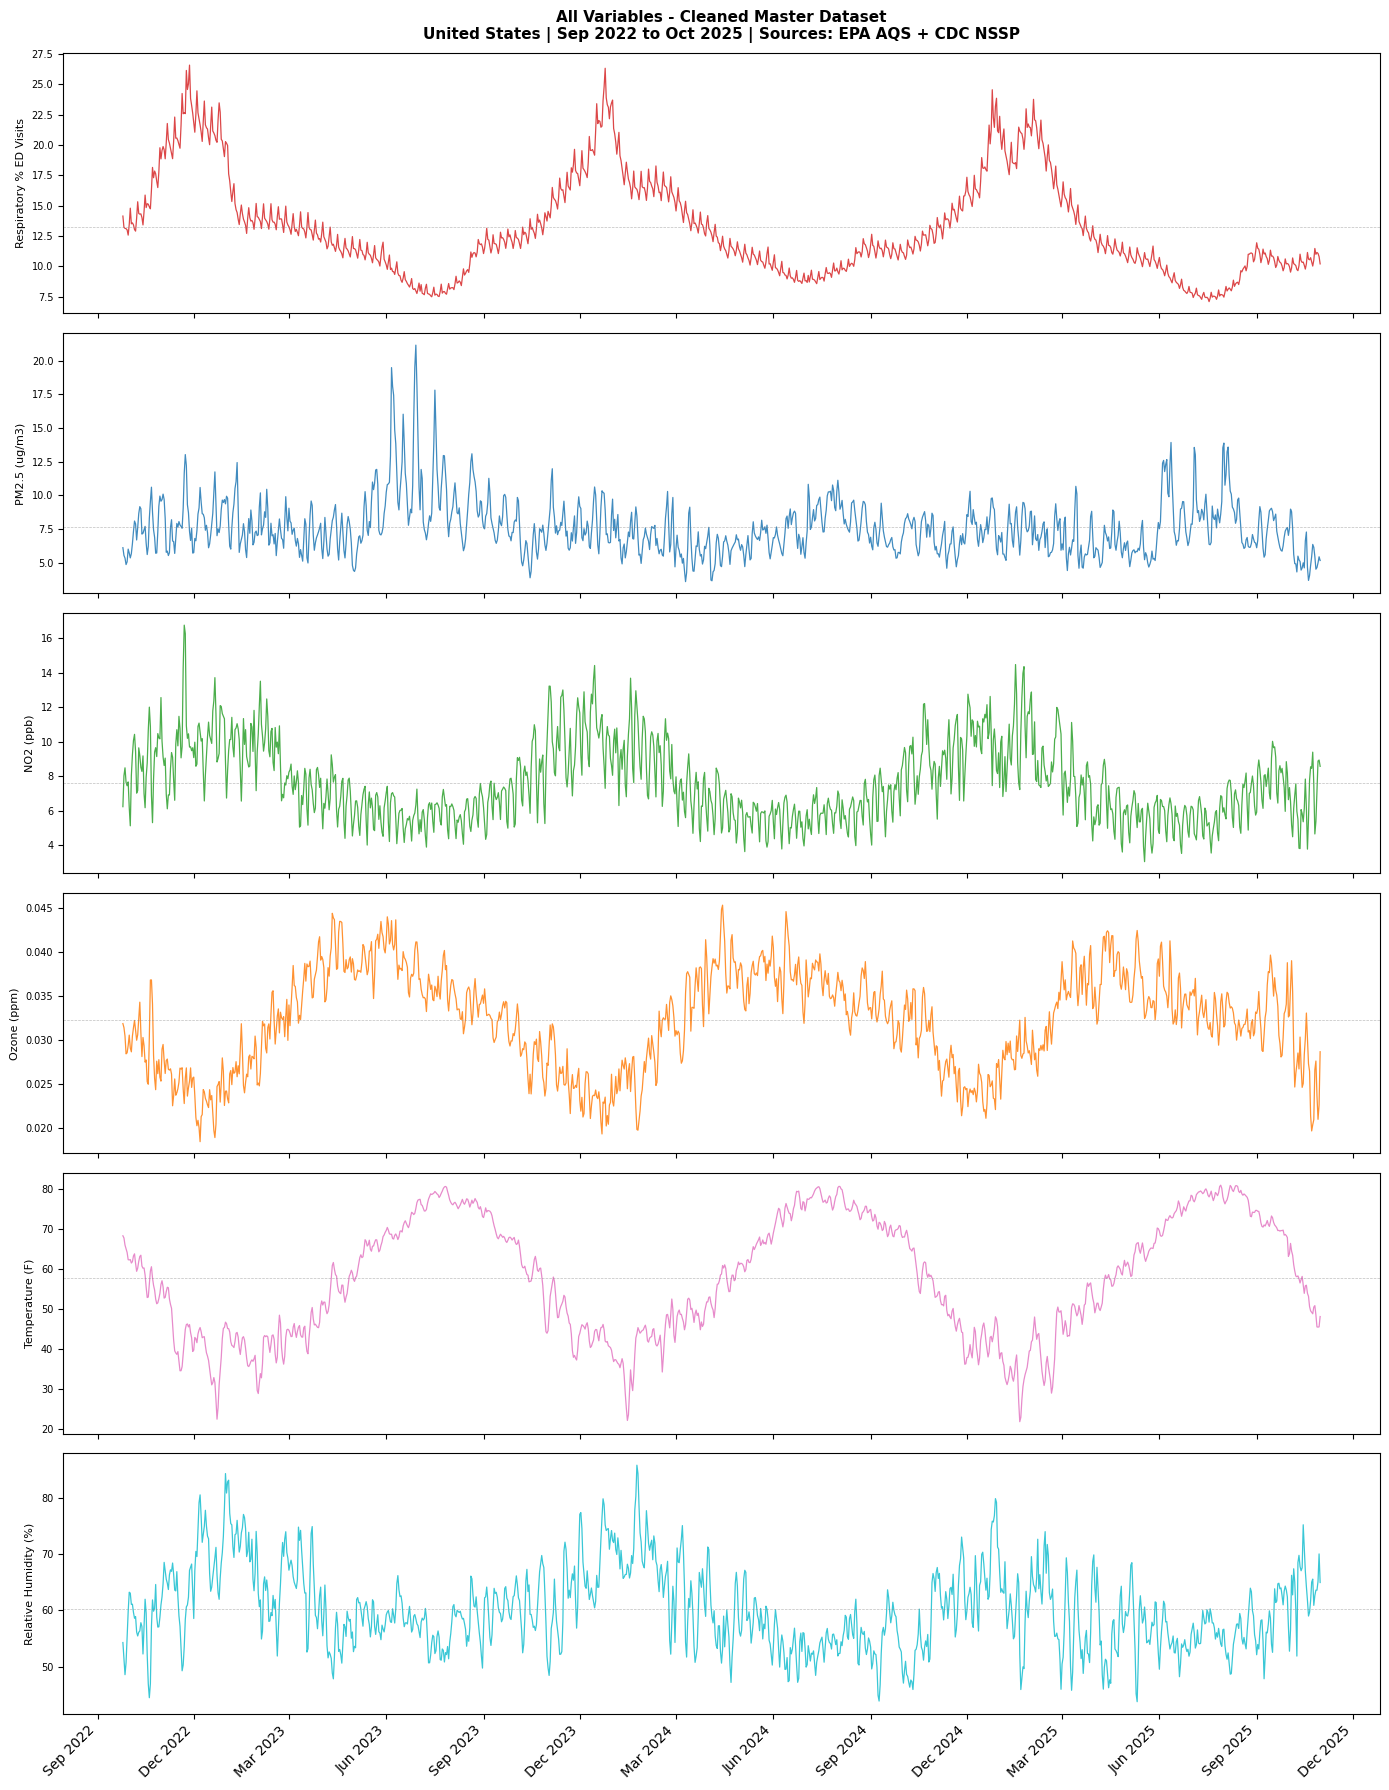

Saved: outputs/figures/cleaned_master_all_variables.png


In [10]:
COLS   = ['pct_respiratory', 'pm25', 'no2', 'ozone', 'temperature', 'humidity']
LABELS = {
    'pct_respiratory': 'Respiratory % ED Visits',
    'pm25':            'PM2.5 (ug/m3)',
    'no2':             'NO2 (ppb)',
    'ozone':           'Ozone (ppm)',
    'temperature':     'Temperature (F)',
    'humidity':        'Relative Humidity (%)',
}
COLORS = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#e377c2', '#17becf']

fig, axes = plt.subplots(len(COLS), 1, figsize=(14, 3 * len(COLS)), sharex=True)

for ax, col, color in zip(axes, COLS, COLORS):
    ax.plot(master['date'], master[col], color=color, linewidth=0.9, alpha=0.85)
    ax.set_ylabel(LABELS[col], fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.axhline(master[col].mean(), color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

axes[0].set_title(
    'All Variables - Cleaned Master Dataset\n'
    'United States | Sep 2022 to Oct 2025 | Sources: EPA AQS + CDC NSSP',
    fontsize=11, fontweight='bold', pad=10
)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/cleaned_master_all_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/cleaned_master_all_variables.png')

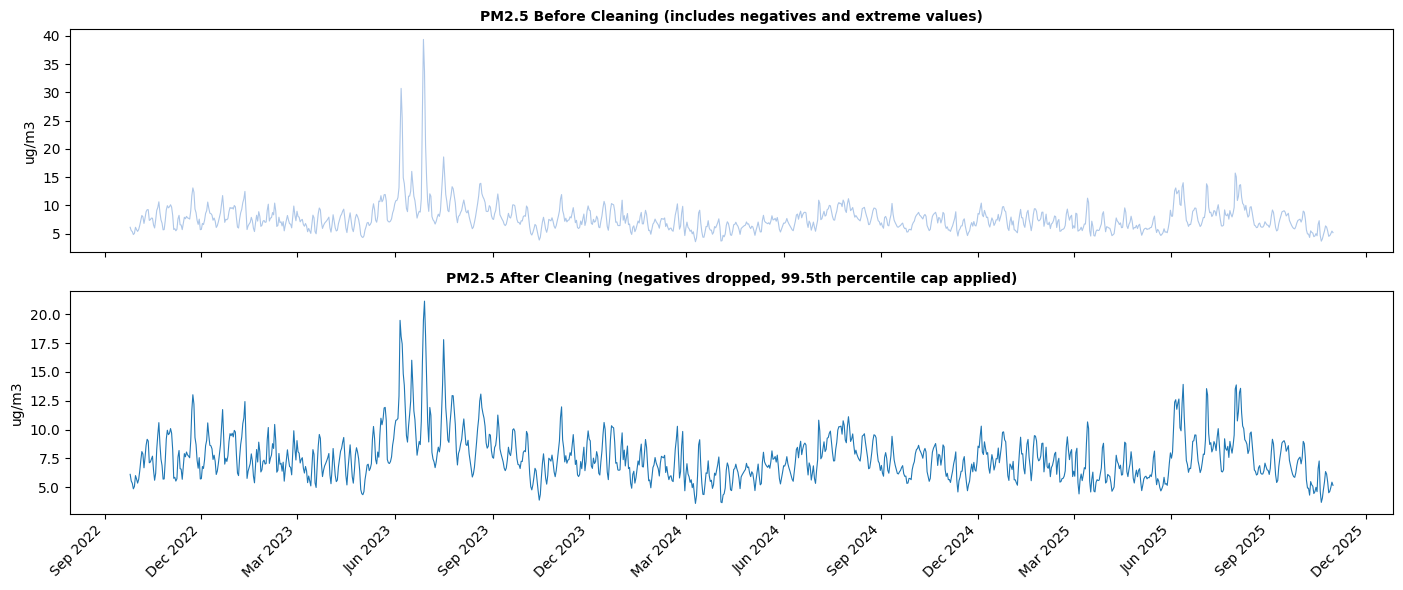

Saved: outputs/figures/pm25_before_after_cleaning.png


In [11]:
# Before vs after comparison for PM2.5
# PM2.5 had the most cleaning applied this confirms the signal is preserved
pm25_raw_daily = (
    pm25_raw.copy()
    .assign(date=lambda x: pd.to_datetime(x['Date Local'], format='mixed', errors='coerce'))
    .assign(value=lambda x: pd.to_numeric(x['Arithmetic Mean'], errors='coerce'))
    .query(f'date >= "{STUDY_START}" and date <= "{STUDY_END}"')
    .groupby('date')['value'].mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(pm25_raw_daily['date'], pm25_raw_daily['value'],
             color='#aec7e8', linewidth=0.8)
axes[0].set_ylabel('ug/m3')
axes[0].set_title('PM2.5 Before Cleaning (includes negatives and extreme values)',
                  fontsize=10, fontweight='bold')

axes[1].plot(master['date'], master['pm25'],
             color='#1f77b4', linewidth=0.8)
axes[1].set_ylabel('ug/m3')
axes[1].set_title('PM2.5 After Cleaning (negatives dropped, 99.5th percentile cap applied)',
                  fontsize=10, fontweight='bold')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/pm25_before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/pm25_before_after_cleaning.png')

---
## Summary

### Steps carried out:

| Dataset | Operation | Count affected | Justification |
|---|---|---|---|
| PM2.5 | Dropped negatives | 8,306 | Physically impossible concentration |
| PM2.5 | Capped at 99.5th pct (38.00 µg/m³) | 11,344 | Preserves wildfire signal, removes extreme errors |
| NO2 | Dropped negatives | 2,694 | Physically impossible concentration |
| NO2 | Capped at 99.5th pct (32.96 ppb) | 2,219 | Standard tail cleanup |
| Ozone | Dropped negatives | 18 | Physically impossible |
| Ozone | Capped at 99.5th pct (0.0623 ppm) | 5,540 | Standard tail cleanup |
| Temperature | Dropped below -80F | 1 | Sentinel value at -1177.67F |
| Temperature | Dropped above 140F | 79 | Surface radiant heat artifacts |
| Humidity | Filtered to RH rows | 43,518 removed | Dew Point rows in wrong units |
| Humidity | Dropped above 100% | 2 | Physically impossible |
| Respiratory | Filtered to ARI + US | ~195,000 removed | By design, not errors |

All counts for negatives and caps reflect the study period (2022-09-25 to 2025-10-31) only.
Percentile caps are computed after the study-period filter so they reflect the actual study distribution.

### Master dataset

- **File:** `data/processed/master_daily.csv`
- **Columns:** date, pct_respiratory, pm25, pm25_n_stations, no2, no2_n_stations, ozone, ozone_n_stations, temperature, temp_n_stations, humidity, humidity_n_stations
- **Date range:** September 25, 2022 to October 31, 2025
- **Missing values:** None (inner join ensures complete rows only)